## Imports & device setup


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

from google.colab import files
uploaded = files.upload()


Using device: cpu


Saving data_loaders.pkl to data_loaders.pkl
Saving trained_mlp.pth to trained_mlp.pth


In [ ]:
!jupyter nbconvert --to python PartB.ipynb

[NbConvertApp] Converting notebook PartB.ipynb to python
[NbConvertApp] Writing 7816 bytes to PartB.py


In [ ]:
import pickle
from PartB import MLP

# Load model weights
model = MLP().to("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("trained_mlp.pth"))
model.eval()

# Load data loaders
with open("data_loaders.pkl", "rb") as f:
    data_objects = pickle.load(f)

train_loader = data_objects['train_loader']
val_loader   = data_objects['val_loader']
test_loader  = data_objects['test_loader']

print("Model and data loaders loaded successfully")

Model and data loaders loaded successfully


## Training function

In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=20, lr=0.01, device=device):
    """
    Train model and return dict with epoch-wise metrics and best model state.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X.size(0)
            preds = outputs.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for Xv, yv in val_loader:
                Xv, yv = Xv.to(device), yv.to(device)
                out = model(Xv)
                loss_v = criterion(out, yv)
                val_running_loss += loss_v.item() * Xv.size(0)
                val_correct += (out.argmax(1) == yv).sum().item()
                val_total += yv.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        # checkpoint best
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch}/{num_epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    return {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "best_val_acc": best_val_acc,
        "best_state": best_state
    }


## Learning rate sweep

In [ ]:
lr_values = [0.001, 0.01, 0.1, 1.0]
num_epochs = 20
lr_results = {}

for lr in lr_values:
    print("\n" + "="*30)
    print(f"Training with learning rate = {lr}")
    print("="*30)
    model = MLP().to(device)
    res = train_model(model, train_loader, val_loader, num_epochs=num_epochs, lr=lr, device=device)
    lr_results[lr] = res



Training with learning rate = 0.001
Epoch 1/20 | train_loss=2.0806 train_acc=0.3191 | val_loss=1.8685 val_acc=0.5114
Epoch 2/20 | train_loss=1.6706 train_acc=0.5987 | val_loss=1.4648 val_acc=0.6709
Epoch 3/20 | train_loss=1.3086 train_acc=0.7034 | val_loss=1.1465 val_acc=0.7401
Epoch 4/20 | train_loss=1.0444 train_acc=0.7581 | val_loss=0.9300 val_acc=0.7833
Epoch 5/20 | train_loss=0.8691 train_acc=0.7913 | val_loss=0.7889 val_acc=0.8107
Epoch 6/20 | train_loss=0.7529 train_acc=0.8143 | val_loss=0.6932 val_acc=0.8271
Epoch 7/20 | train_loss=0.6721 train_acc=0.8294 | val_loss=0.6255 val_acc=0.8394
Epoch 8/20 | train_loss=0.6134 train_acc=0.8407 | val_loss=0.5750 val_acc=0.8502
Epoch 9/20 | train_loss=0.5687 train_acc=0.8497 | val_loss=0.5362 val_acc=0.8581
Epoch 10/20 | train_loss=0.5337 train_acc=0.8572 | val_loss=0.5052 val_acc=0.8638
Epoch 11/20 | train_loss=0.5056 train_acc=0.8640 | val_loss=0.4805 val_acc=0.8709
Epoch 12/20 | train_loss=0.4825 train_acc=0.8696 | val_loss=0.4595 val

## Plot learning rate results

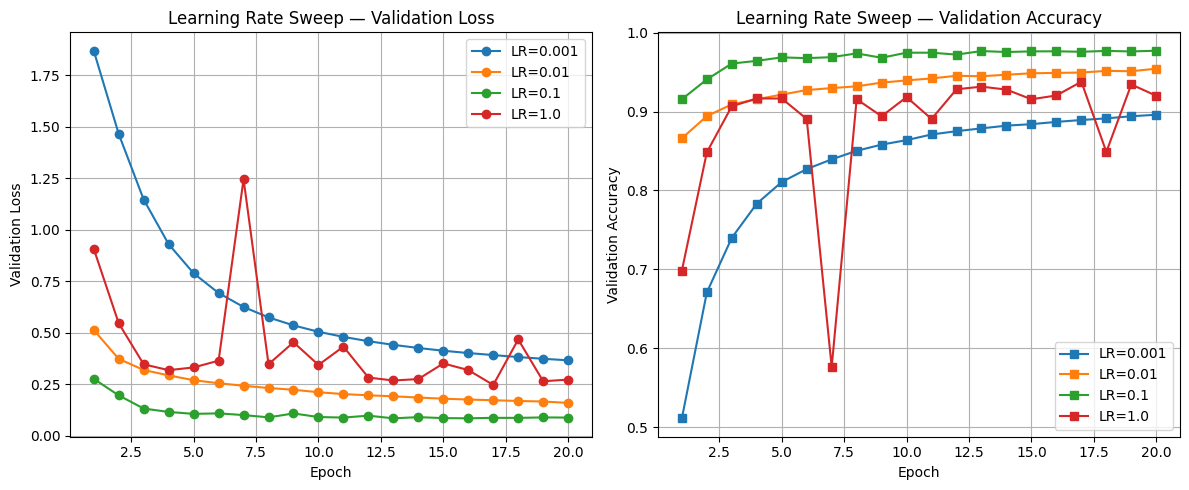

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for lr, res in lr_results.items():
    epochs = range(1, len(res['val_losses']) + 1)
    plt.plot(epochs, res['val_losses'], marker='o', label=f"LR={lr}")
plt.xlabel("Epoch"); plt.ylabel("Validation Loss")
plt.title("Learning Rate Sweep — Validation Loss")
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
for lr, res in lr_results.items():
    epochs = range(1, len(res['val_accs']) + 1)
    plt.plot(epochs, res['val_accs'], marker='s', label=f"LR={lr}")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.title("Learning Rate Sweep — Validation Accuracy")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()


## Batch size analysis

In [ ]:
batch_sizes = [16, 32, 64, 128]
num_epochs = 20
lr = 0.1  # Best LR from sweep
bs_results = {}

train_dataset = data_objects['train_dataset']
val_dataset   = data_objects['val_dataset']

for bs in batch_sizes:
    print("\n" + "="*40)
    print(f"Training with batch size = {bs}")
    print("="*40)
    train_loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    val_loader_bs   = DataLoader(val_dataset, batch_size=bs, shuffle=False)
    model = MLP().to(device)
    res = train_model(model, train_loader_bs, val_loader_bs, num_epochs=num_epochs, lr=lr, device=device)
    bs_results[bs] = res



Training with batch size = 16
Epoch 1/20 | train_loss=0.5579 train_acc=0.8479 | val_loss=0.2992 val_acc=0.9126
Epoch 2/20 | train_loss=0.2747 train_acc=0.9205 | val_loss=0.2313 val_acc=0.9337
Epoch 3/20 | train_loss=0.2181 train_acc=0.9371 | val_loss=0.1955 val_acc=0.9423
Epoch 4/20 | train_loss=0.1816 train_acc=0.9477 | val_loss=0.1763 val_acc=0.9479
Epoch 5/20 | train_loss=0.1556 train_acc=0.9552 | val_loss=0.1571 val_acc=0.9540
Epoch 6/20 | train_loss=0.1368 train_acc=0.9606 | val_loss=0.1473 val_acc=0.9577
Epoch 7/20 | train_loss=0.1208 train_acc=0.9648 | val_loss=0.1344 val_acc=0.9606
Epoch 8/20 | train_loss=0.1081 train_acc=0.9684 | val_loss=0.1362 val_acc=0.9595
Epoch 9/20 | train_loss=0.0980 train_acc=0.9712 | val_loss=0.1229 val_acc=0.9632
Epoch 10/20 | train_loss=0.0881 train_acc=0.9751 | val_loss=0.1170 val_acc=0.9655
Epoch 11/20 | train_loss=0.0801 train_acc=0.9765 | val_loss=0.1116 val_acc=0.9679
Epoch 12/20 | train_loss=0.0727 train_acc=0.9791 | val_loss=0.1089 val_acc=0

## Plot batch size results

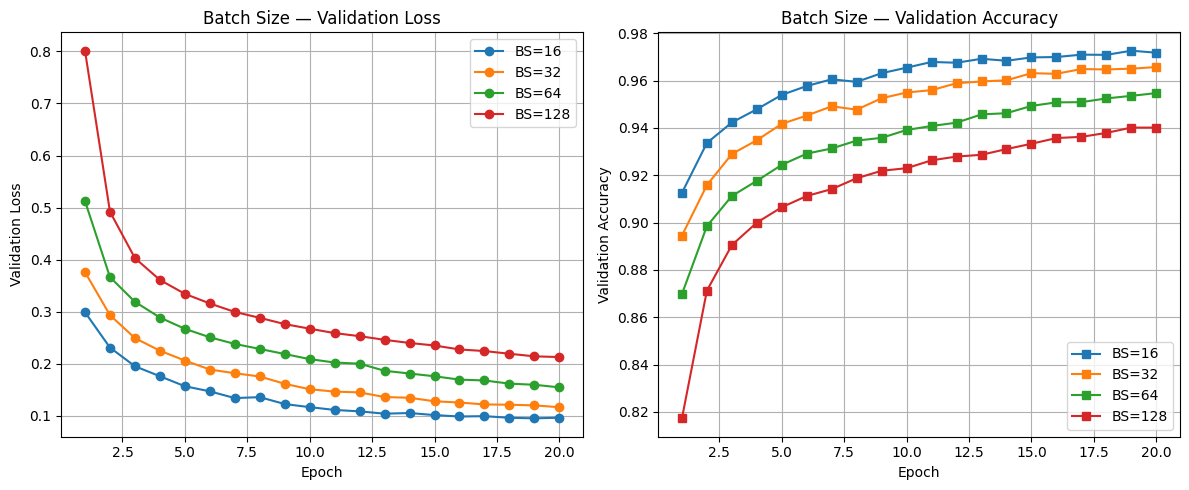

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for bs, res in bs_results.items():
    epochs = range(1, len(res['val_losses']) + 1)
    plt.plot(epochs, res['val_losses'], marker='o', label=f"BS={bs}")
plt.xlabel("Epoch"); plt.ylabel("Validation Loss")
plt.title("Batch Size — Validation Loss")
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
for bs, res in bs_results.items():
    epochs = range(1, len(res['val_accs']) + 1)
    plt.plot(epochs, res['val_accs'], marker='s', label=f"BS={bs}")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.title("Batch Size — Validation Accuracy")
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.show()


## Define FlexibleMLP (architecture testing)

In [ ]:
class FlexibleMLP(nn.Module):
    def __init__(self, input_size=28*28, hidden_layers=[128, 64], output_size=10):
        super(FlexibleMLP, self).__init__()
        layers = []
        in_features = input_size
        for h in hidden_layers:
            layers.append(nn.Linear(in_features, h))
            layers.append(nn.ReLU())
            in_features = h
        layers.append(nn.Linear(in_features, output_size))
        self.network = nn.Sequential(*layers)
        # Weight init
        for m in self.network:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)


## Architecture analysis

In [ ]:
architectures = {
    "2 layers (128,64)": [128, 64],
    "3 layers (128,64,32)": [128, 64, 32],
    "4 layers (256,128,64,32)": [256, 128, 64, 32],
    "5 layers (512,256,128,64,32)": [512, 256, 128, 64, 32],
}
num_epochs = 20
lr = 0.1
arch_results = {}

for name, hidden_layers in architectures.items():
    print("\n" + "="*40)
    print(f"Training architecture: {name}")
    print("="*40)
    model = FlexibleMLP(hidden_layers=hidden_layers).to(device)
    res = train_model(model, train_loader, val_loader, num_epochs=num_epochs, lr=lr, device=device)
    arch_results[name] = res



Training architecture: 2 layers (128,64)
Epoch 1/20 | train_loss=0.9512 train_acc=0.7589 | val_loss=0.4776 val_acc=0.8729
Epoch 2/20 | train_loss=0.4196 train_acc=0.8842 | val_loss=0.3601 val_acc=0.8980
Epoch 3/20 | train_loss=0.3474 train_acc=0.9008 | val_loss=0.3185 val_acc=0.9088
Epoch 4/20 | train_loss=0.3116 train_acc=0.9097 | val_loss=0.2890 val_acc=0.9146
Epoch 5/20 | train_loss=0.2863 train_acc=0.9169 | val_loss=0.2689 val_acc=0.9221
Epoch 6/20 | train_loss=0.2663 train_acc=0.9236 | val_loss=0.2567 val_acc=0.9250
Epoch 7/20 | train_loss=0.2500 train_acc=0.9280 | val_loss=0.2427 val_acc=0.9300
Epoch 8/20 | train_loss=0.2348 train_acc=0.9320 | val_loss=0.2295 val_acc=0.9344
Epoch 9/20 | train_loss=0.2220 train_acc=0.9361 | val_loss=0.2180 val_acc=0.9372
Epoch 10/20 | train_loss=0.2103 train_acc=0.9397 | val_loss=0.2081 val_acc=0.9407
Epoch 11/20 | train_loss=0.1993 train_acc=0.9428 | val_loss=0.2020 val_acc=0.9431
Epoch 12/20 | train_loss=0.1897 train_acc=0.9453 | val_loss=0.195

## Plot architecture results

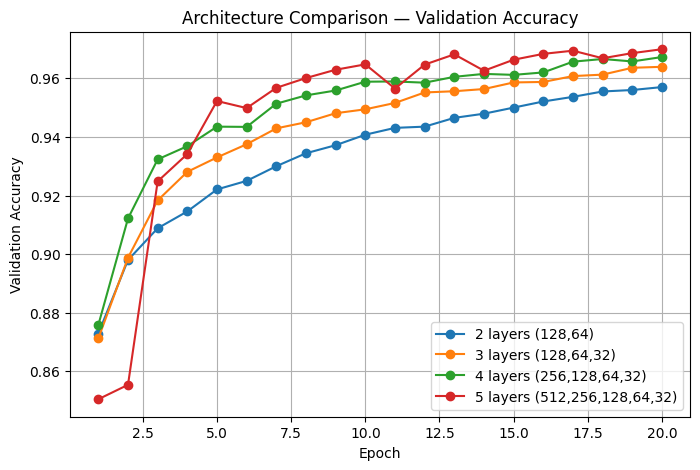

In [ ]:

plt.figure(figsize=(8,5))
for name, res in arch_results.items():
    epochs = range(1, len(res['val_accs']) + 1)
    plt.plot(epochs, res['val_accs'], marker='o', label=name)
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Architecture Comparison — Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## Architecture summary table

In [ ]:
summary = []
for name, res in arch_results.items():
    summary.append({
        "Architecture": name,
        "Final Val Acc": round(res['val_accs'][-1], 4),
        "Best Val Acc": round(res['best_val_acc'], 4)
    })
arch_df = pd.DataFrame(summary)
print(arch_df)


                   Architecture  Final Val Acc  Best Val Acc
0             2 layers (128,64)         0.9570        0.9570
1          3 layers (128,64,32)         0.9639        0.9639
2      4 layers (256,128,64,32)         0.9673        0.9673
3  5 layers (512,256,128,64,32)         0.9699        0.9699


In [ ]:
from torch.utils.data import ConcatDataset

# Combine train + val for final training
full_train_dataset = ConcatDataset([train_dataset, val_dataset])

best_lr = 0.1
best_batch = 32
best_arch = [512, 256, 128, 64, 32]

test_dataset = data_objects['test_dataset']

full_train_loader = DataLoader(full_train_dataset, batch_size=best_batch, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_batch, shuffle=False)


In [ ]:
import time
best_model = FlexibleMLP(hidden_layers=best_arch).to(device)

start_time = time.time()

final_results = train_model(
    best_model,
    full_train_loader,
    test_loader,
    num_epochs=20,
    lr=best_lr,
    device=device
)

end_time = time.time()
train_time = end_time - start_time
print(f"\n Total training time: {train_time:.2f} seconds")



Epoch 1/20 | train_loss=0.4998 train_acc=0.8508 | val_loss=0.2197 val_acc=0.9350
Epoch 2/20 | train_loss=0.1933 train_acc=0.9435 | val_loss=0.1678 val_acc=0.9485
Epoch 3/20 | train_loss=0.1403 train_acc=0.9584 | val_loss=0.1434 val_acc=0.9547
Epoch 4/20 | train_loss=0.1095 train_acc=0.9677 | val_loss=0.1297 val_acc=0.9596
Epoch 5/20 | train_loss=0.0878 train_acc=0.9735 | val_loss=0.1060 val_acc=0.9673
Epoch 6/20 | train_loss=0.0723 train_acc=0.9787 | val_loss=0.0988 val_acc=0.9696
Epoch 7/20 | train_loss=0.0582 train_acc=0.9833 | val_loss=0.0981 val_acc=0.9702
Epoch 8/20 | train_loss=0.0464 train_acc=0.9867 | val_loss=0.0971 val_acc=0.9693
Epoch 9/20 | train_loss=0.0392 train_acc=0.9890 | val_loss=0.0955 val_acc=0.9708
Epoch 10/20 | train_loss=0.0323 train_acc=0.9912 | val_loss=0.0976 val_acc=0.9715
Epoch 11/20 | train_loss=0.0252 train_acc=0.9931 | val_loss=0.0931 val_acc=0.9719
Epoch 12/20 | train_loss=0.0206 train_acc=0.9951 | val_loss=0.0912 val_acc=0.9734
Epoch 13/20 | train_loss=


Final Test Accuracy = 0.9748


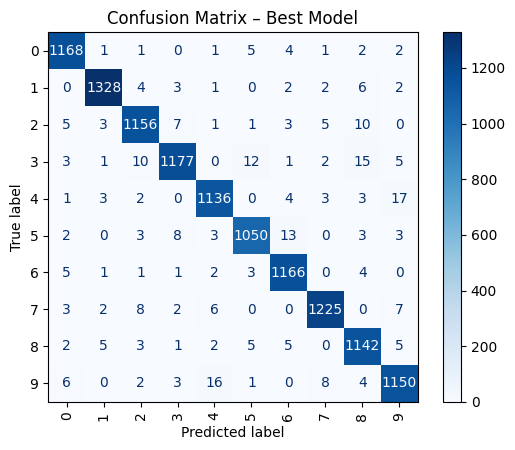

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model.eval()
correct, total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = best_model(X)
        preds = outputs.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

test_acc = correct / total
print(f"\nFinal Test Accuracy = {test_acc:.4f}")

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title("Confusion Matrix – Best Model")
plt.show()


In [43]:
X_train_t = torch.cat([X.view(X.size(0), -1) for X, _ in train_loader])
Y_train_t = torch.cat([y for _, y in train_loader])

X_val_t = torch.cat([X.view(X.size(0), -1) for X, _ in val_loader])
Y_val_t = torch.cat([y for _, y in val_loader])

  # Filter for digits 0 and 1, and convert labels to float
train_filter_indices = (Y_train_t == 0) | (Y_train_t == 1)
filtered_X_train_t = X_train_t[train_filter_indices]
filtered_Y_train_t = Y_train_t[train_filter_indices].float()

val_filter_indices = (Y_val_t == 0) | (Y_val_t == 1)
filtered_X_val_t = X_val_t[val_filter_indices]
filtered_Y_val_t = Y_val_t[val_filter_indices].float()


In [39]:
import torch
import numpy as np

def train_logistic_regression(model, train_loader, val_loader, learning_rate=0.01, epochs=20):
    W, b = model
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    binary_cross_entropy = torch.nn.BCELoss()

    for epoch in range(epochs):
        total_train_loss, correct_train, total_train = 0, 0, 0

        for X_batch, y_batch in train_loader:
            y_true = y_batch.float().view(-1, 1)
            y_pred = torch.sigmoid(X_batch @ W + b)
            loss = binary_cross_entropy(y_pred, y_true)

            loss.backward()
            with torch.no_grad():
                W -= learning_rate * W.grad
                b -= learning_rate * b.grad
            W.grad.zero_()
            b.grad.zero_()

            predictions = (y_pred > 0.5).float()
            correct_train += (predictions == y_true).sum().item()
            total_train += y_true.size(0)
            total_train_loss += loss.item() * y_true.size(0)

        train_loss = total_train_loss / total_train
        train_acc = 100 * correct_train / total_train

        # Validation
        total_val_loss, correct_val, total_val = 0, 0, 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                y_true = y_val.float().view(-1, 1)
                y_pred = torch.sigmoid(X_val @ W + b)
                loss = binary_cross_entropy(y_pred, y_true)

                predictions = (y_pred > 0.5).float()
                correct_val += (predictions == y_true).sum().item()
                total_val += y_true.size(0)
                total_val_loss += loss.item() * y_true.size(0)

        val_loss = total_val_loss / total_val
        val_acc = 100 * correct_val / total_val

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return train_losses, val_losses, train_accs, val_accs


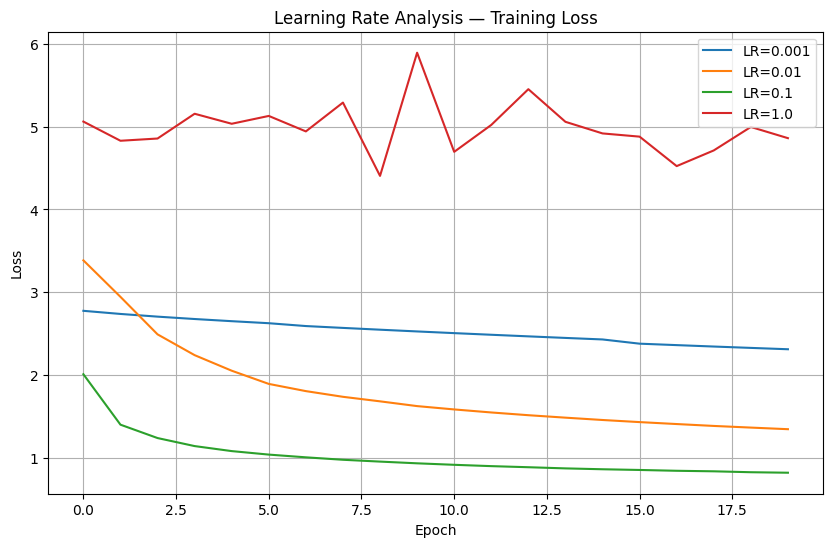

In [44]:
from torch.utils.data import DataLoader, TensorDataset

learning_rates = [0.001, 0.01, 0.1, 1.0]
epochs = 20

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    # Reinitialize parameters for each run
    W = torch.randn(X_train_t.shape[1], 1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    model = (W,b)


    train_loader_lr = DataLoader(TensorDataset(filtered_X_train_t, filtered_Y_train_t), batch_size=64, shuffle=True)
    val_loader_lr = DataLoader(TensorDataset(filtered_X_val_t, filtered_Y_val_t), batch_size=64, shuffle=False)

    train_losses, val_losses, _, _ = train_logistic_regression(model, train_loader_lr, val_loader_lr, learning_rate=lr, epochs=epochs)
    plt.plot(train_losses, label=f"LR={lr}")

plt.title("Learning Rate Analysis — Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

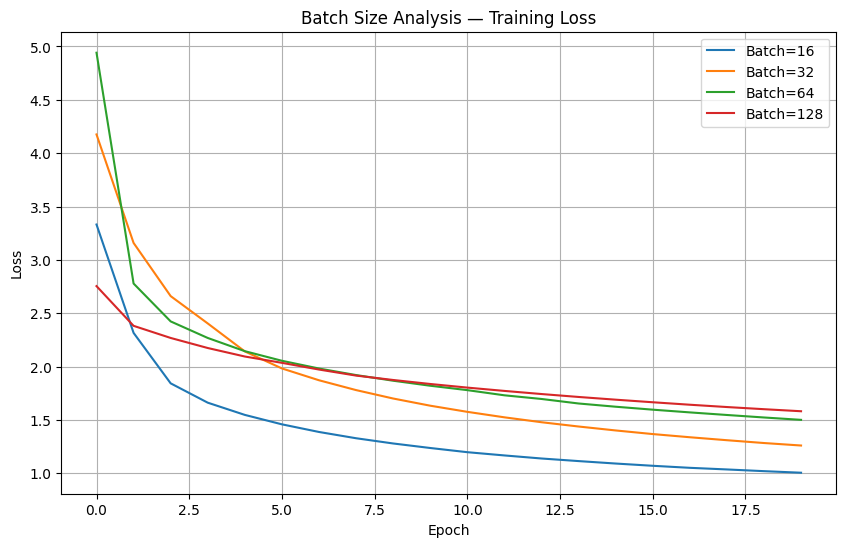

In [45]:
batch_sizes = [16, 32, 64, 128]
epochs = 20
lr = 0.01

plt.figure(figsize=(10, 6))
for bs in batch_sizes:
    W = torch.randn(X_train_t.shape[1], 1, requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    model = (W, b)


    train_loader_bs = DataLoader(TensorDataset(filtered_X_train_t, filtered_Y_train_t), batch_size=bs, shuffle=True)
    val_loader_bs = DataLoader(TensorDataset(filtered_X_val_t, filtered_Y_val_t), batch_size=bs, shuffle=False)

    train_losses, val_losses, _, _ = train_logistic_regression(model, train_loader_bs, val_loader_bs, learning_rate=lr, epochs=epochs)
    plt.plot(train_losses, label=f"Batch={bs}")

plt.title("Batch Size Analysis — Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [46]:

def train_softmax_regression(model, train_loader, val_loader, learning_rate=0.01, epochs=20):
    W, b = model
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    cross_entropy = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_train_loss, correct_train, total_train = 0, 0, 0

        for X_batch, y_batch in train_loader:

            logits = X_batch @ W + b
            loss = cross_entropy(logits, y_batch)

            # Backward
            loss.backward()
            with torch.no_grad():
                W -= learning_rate * W.grad
                b -= learning_rate * b.grad
            W.grad.zero_()
            b.grad.zero_()

            # Accuracy
            preds = torch.argmax(logits, dim=1)
            correct_train += (preds == y_batch).sum().item()
            total_train += y_batch.size(0)
            total_train_loss += loss.item() * y_batch.size(0)

        train_loss = total_train_loss / total_train
        train_acc = 100 * correct_train / total_train

        # Validation
        total_val_loss, correct_val, total_val = 0, 0, 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                logits = X_val @ W + b
                loss = cross_entropy(logits, y_val)
                preds = torch.argmax(logits, dim=1)
                correct_val += (preds == y_val).sum().item()
                total_val += y_val.size(0)
                total_val_loss += loss.item() * y_val.size(0)

        val_loss = total_val_loss / total_val
        val_acc = 100 * correct_val / total_val

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

    return train_losses, val_losses, train_accs, val_accs


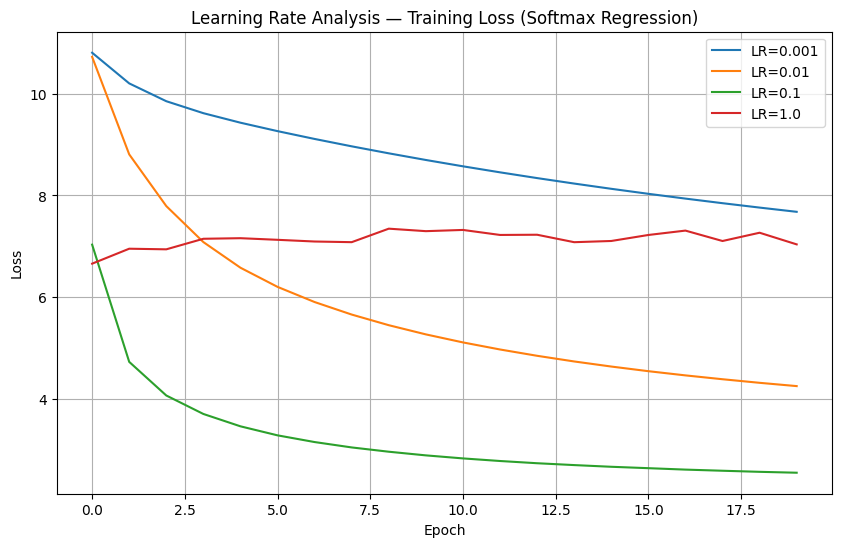

In [47]:
learning_rates = [0.001, 0.01, 0.1, 1.0]
epochs = 20
num_classes = len(torch.unique(Y_train_t))

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    # Reinitialize parameters each run
    W = torch.randn(X_train_t.shape[1], num_classes, requires_grad=True)
    b = torch.zeros(num_classes, requires_grad=True)
    model = (W,b)

    train_loader_lr = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=64, shuffle=True)
    val_loader_lr = DataLoader(TensorDataset(X_val_t, Y_val_t), batch_size=64, shuffle=False)

    train_losses, val_losses, _, _ = train_softmax_regression(model, train_loader_lr, val_loader_lr, learning_rate=lr, epochs=epochs)
    plt.plot(train_losses, label=f"LR={lr}")

plt.title("Learning Rate Analysis — Training Loss (Softmax Regression)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


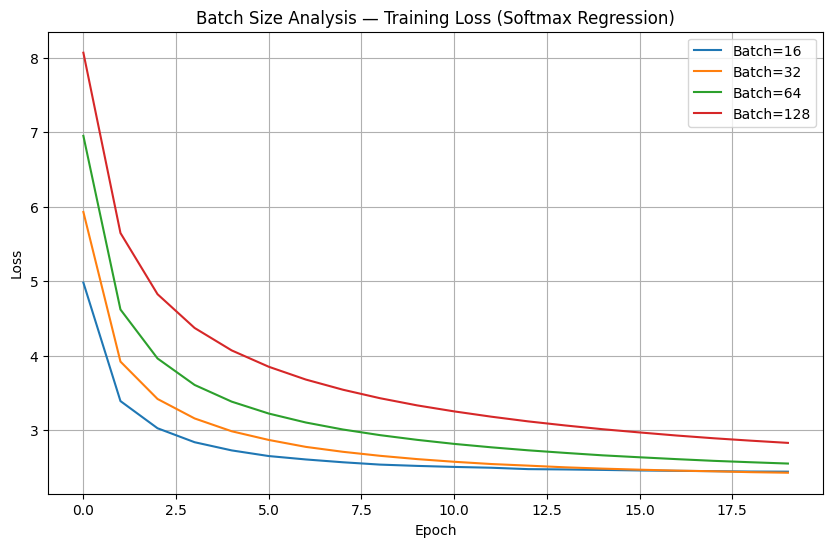

In [48]:
batch_sizes = [16, 32, 64, 128]
epochs = 20
lr = 0.1
num_classes = len(torch.unique(Y_train_t))

plt.figure(figsize=(10, 6))
for bs in batch_sizes:

    # Reinitialize parameters each run
    W = torch.randn(X_train_t.shape[1], num_classes, requires_grad=True)
    b = torch.zeros(num_classes, requires_grad=True)
    model = (W,b)

    train_loader_bs = DataLoader(TensorDataset(X_train_t, Y_train_t), batch_size=bs, shuffle=True)
    val_loader_bs = DataLoader(TensorDataset(X_val_t, Y_val_t), batch_size=bs, shuffle=False)

    train_losses, val_losses, _, _ = train_softmax_regression(model, train_loader_bs, val_loader_bs, learning_rate=lr, epochs=epochs)
    plt.plot(train_losses, label=f"Batch={bs}")

plt.title("Batch Size Analysis — Training Loss (Softmax Regression)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()
